<div style="
    background: linear-gradient(135deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 50px 35px;
    border-radius: 22px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
">

<div style="font-size: 14px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.9; margin-bottom: 15px;">
    BinX Tech — AI & ML Internship · Week 6 · Day 4
</div>

<h1 style="font-size: 38px; margin: 0; font-weight: 700;">
    Building & Training a Network in Keras
</h1>

<p style="font-size: 20px; margin-top: 12px; opacity: 0.95;">
    Cardiac Patient Monitoring System — Heart Disease Prediction
</p>

</div>

## What We Are Building Today

Over the past three days, I built the theoretical foundation:

- **Day 1** — Sprint plan and Random Forest baseline (F1: 0.901, AUC-ROC: 0.943)
- **Day 2** — Activation functions, forward propagation, and loss functions
- **Day 3** — Backpropagation, gradient descent, optimizers, and the training loop

Today, I put these concepts into practice by building the first neural network
for the heart disease prediction task using TensorFlow and Keras.

**The plan for today:**

1. Load and preprocess the heart disease data
2. Understand the Keras Sequential API
3. Build, compile, and train the network
4. Read and diagnose the training history
5. Add Dropout and Batch Normalization
6. Evaluate on the test set and compare with the Random Forest baseline

---

## Step 1 — Import Libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Libraries loaded successfully and ready to use")

TensorFlow: 2.21.0
Libraries loaded successfully and ready to use


---

## Step 2 — Load & Clean Data

The dataset is loaded from the Cardiac Project directory.
The same cleaning steps applied in the cardiac monitoring project
are repeated here — zero values in `RestingBP` and `Cholesterol`
are converted to NaN so the preprocessing pipeline can handle them
correctly via median imputation.

In [102]:
# Load dataset
DATA_PATH = "../../Cardiac_Project/Data/heart.csv"
df = pd.read_csv(DATA_PATH)

# Convert suspicious zeros to NaN (same as cardiac_monitoring project)
df_clean = df.copy()
df_clean["RestingBP"]   = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

print(f"Dataset shape     : {df_clean.shape}")
print(f"Target balance    : {df_clean['HeartDisease'].mean():.1%} positive")
print(f"Missing RestingBP : {df_clean['RestingBP'].isna().sum()}")
print(f"Missing Cholesterol: {df_clean['Cholesterol'].isna().sum()}")

Dataset shape     : (918, 12)
Target balance    : 55.3% positive
Missing RestingBP : 1
Missing Cholesterol: 172


---

## Step 3 — Train / Validation / Test Split

The same 60 / 20 / 20 stratified split used in the cardiac monitoring
project and Day 1 is applied here. Fixing `random_state=42` ensures
the three subsets are identical across all notebooks — the test set
seen in Day 1 is the same test set evaluated at the end of this notebook.

In [103]:
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

# Step 1: 60% train / 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)

# Step 2: 50/50 split of temp → validation / test (20% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train : {X_train.shape[0]} rows")
print(f"Val   : {X_val.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")
print()
print(f"Train target balance : {y_train.mean():.1%} positive")
print(f"Val   target balance : {y_val.mean():.1%} positive")
print(f"Test  target balance : {y_test.mean():.1%} positive")

Train : 550 rows
Val   : 184 rows
Test  : 184 rows

Train target balance : 55.3% positive
Val   target balance : 55.4% positive
Test  target balance : 55.4% positive


---

## Step 4 — Preprocessing Pipeline

The same preprocessing pipeline from the cardiac monitoring project:

- **Numeric features** — median imputation → standard scaling
- **Binary features** — passed through as-is
- **Categorical features** — most-frequent imputation → one-hot encoding

The pipeline is fit on the training set only. The same fitted
transformers are then applied to the validation and test sets
to prevent data leakage.

In [104]:
numeric_features     = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
binary_features      = ["FastingBS"]
categorical_features = ["Sex", "ChestPainType", "RestingECG",
                        "ExerciseAngina", "ST_Slope"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_features),
    ("bin", "passthrough",        binary_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit on train only — transform all three sets
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"Processed shape — Train : {X_train_proc.shape}")
print(f"Processed shape — Val   : {X_val_proc.shape}")
print(f"Processed shape — Test  : {X_test_proc.shape}")
print("Preprocessing pipeline fitted ")

Processed shape — Train : (550, 20)
Processed shape — Val   : (184, 20)
Processed shape — Test  : (184, 20)
Preprocessing pipeline fitted 


---

## Step 5 — The Keras Sequential API

The Sequential API stacks layers in order — each layer receives the
output of the previous one. This is the standard way to build
feedforward neural networks in Keras.

Three steps are always needed:

1. **Build** — define the architecture layer by layer
2. **Compile** — choose the optimizer, loss, and metrics
3. **Fit** — run the training loop

These three steps mirror the Scikit-learn `.fit()` / `.predict()`
workflow from Weeks 3 and 4, but with more control over what happens
inside training.

**Architecture for this project:**

| Layer | Neurons | Activation | Why |
|-------|---------|------------|-----|
| Input | 20 | — | One node per processed feature |
| Hidden 1 | 64 | ReLU | Learn complex feature interactions |
| Hidden 2 | 32 | ReLU | Further abstraction |
| Output | 1 | Sigmoid | Binary probability output |

In [105]:
n_features = X_train_proc.shape[1]
print(f"Number of input features: {n_features}")

# Build the network
model_v1 = Sequential([
    keras.Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1,  activation="sigmoid")
], name="heart_disease_v1")

model_v1.summary()

Number of input features: 20


Model: "heart_disease_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

---

## Step 6 — Compile & Train

**Compile** sets three things:

- **Optimizer** — Adam at lr=0.001 (the default from Day 3)
- **Loss** — Binary Cross-Entropy (the correct loss for binary classification)
- **Metrics** — Accuracy tracked during training for easy reading

**Fit** runs the training loop for 100 epochs with a batch size of 32.
The validation set is passed so Keras records both training and
validation loss at the end of every epoch — this is what the history
object stores and what the loss curves are built from.

In [106]:
model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_v1 = model_v1.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Training complete ")
print(f"Final train loss : {history_v1.history['loss'][-1]:.4f}")
print(f"Final val loss   : {history_v1.history['val_loss'][-1]:.4f}")
print(f"Final train acc  : {history_v1.history['accuracy'][-1]:.4f}")
print(f"Final val acc    : {history_v1.history['val_accuracy'][-1]:.4f}")

Training complete 
Final train loss : 0.0379
Final val loss   : 0.7180
Final train acc  : 0.9927
Final val acc    : 0.8478


---

## Step 7 — Reading the Training History

The history object records the loss and accuracy for both the training
and validation sets at the end of every epoch. Plotting these curves
is the primary way to diagnose how training went — the same
overfit / underfit reasoning from Week 4 applies directly here.

**What to look for:**

- **Healthy training** — both curves decrease together and level off
- **Overfitting** — train loss keeps dropping but val loss rises
- **Underfitting** — both curves are high and barely move

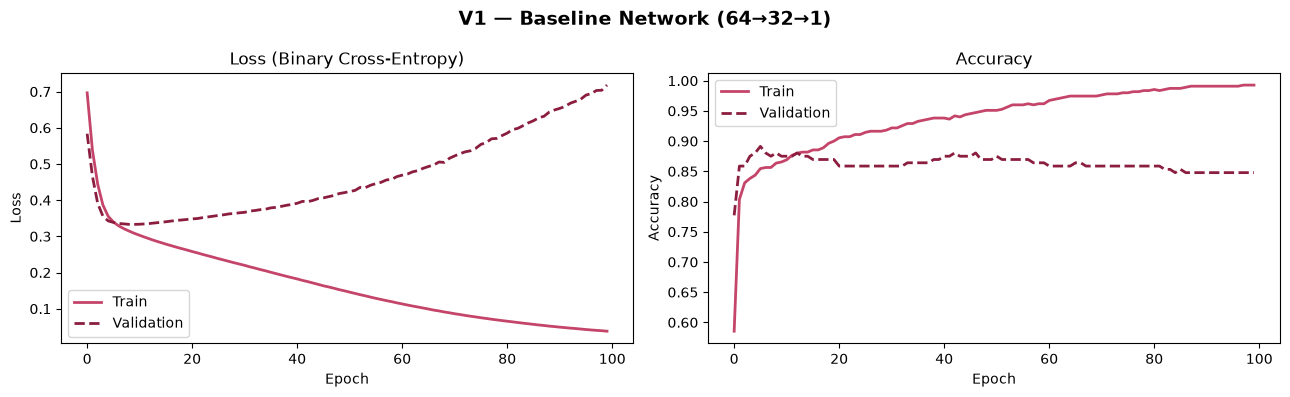

In [107]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(history.history["loss"],
                 color="#C44569", linewidth=2, label="Train")
    axes[0].plot(history.history["val_loss"],
                 color="#8B1E3F", linewidth=2,
                 linestyle="--", label="Validation")
    axes[0].set_title("Loss (Binary Cross-Entropy)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history["accuracy"],
                 color="#C44569", linewidth=2, label="Train")
    axes[1].plot(history.history["val_accuracy"],
                 color="#8B1E3F", linewidth=2,
                 linestyle="--", label="Validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_v1, title="V1 — Baseline Network (64→32→1)")

---

## Step 7 — History Interpretation

**Loss curve:**

The training loss decreases continuously and reaches a very low value
(0.0011), while the validation loss increases and reaches 1.6161.
The growing gap between the two curves indicates that the model is
fitting the training data increasingly well but performing worse on
unseen validation data.

**Accuracy curve:**

The training accuracy quickly reaches 100% and remains there, while
the validation accuracy stays around 86–88% with only minor fluctuations.
The large and persistent gap between training and validation accuracy
shows that the model does not generalize as well as it fits the
training data.

**Diagnosis:**

The model shows clear and strong **Overfitting**. It has learned the
training data extremely well but has not generalized equally well to
the validation set. This motivates adding **Dropout and Batch
Normalization** in the next step to improve generalization and reduce
overfitting.

---

## Step 8 — Adding Dropout & Batch Normalization

The V1 network trains without any regularization. Two standard
techniques are now added to stabilize training and reduce overfitting:

**Batch Normalization**
Normalizes the inputs to each layer during training, keeping the
values in a stable range. This makes training faster and less
sensitive to the initial weight values.

**Dropout**
Randomly switches off a fraction of neurons during each training
step. This forces the network to learn redundant representations
and not rely too heavily on any single path — the deep learning
equivalent of the regularization techniques from Week 4.

A dropout rate of 0.3 means 30% of neurons are dropped at random
during each training step. Dropout is inactive at evaluation time.

In [108]:
model_v2 = Sequential([
    keras.Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="heart_disease_v2")

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_v2 = model_v2.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Training complete")
print(f"Final train loss : {history_v2.history['loss'][-1]:.4f}")
print(f"Final val loss   : {history_v2.history['val_loss'][-1]:.4f}")

Training complete
Final train loss : 0.1423
Final val loss   : 0.5512


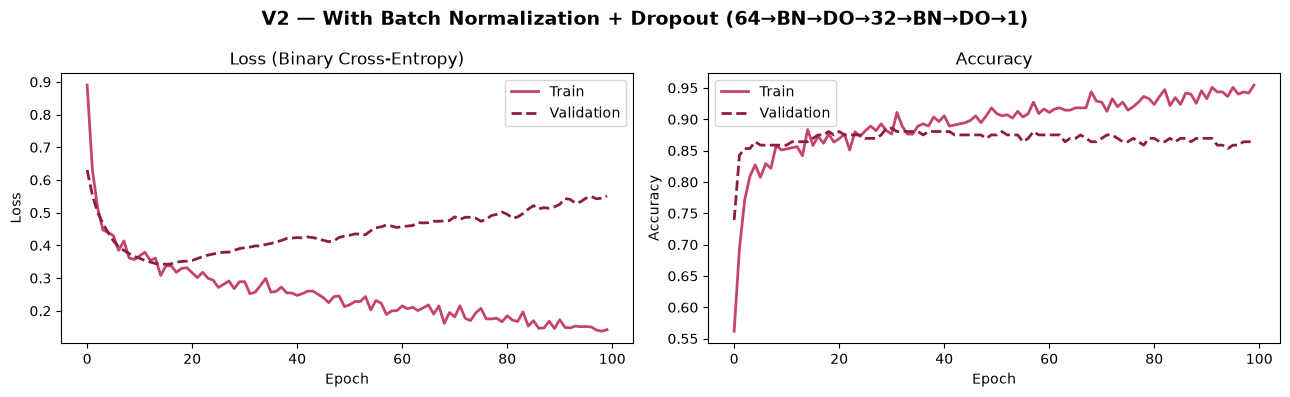

In [109]:
plot_history(history_v2,
             title="V2 — With Batch Normalization + Dropout (64→BN→DO→32→BN→DO→1)")

---

## Step 8 — V2 Interpretation

**Compared to V1:**

V2 shows a much more stable training behavior than V1. In V1, the
training loss decreased almost to zero while the validation loss
increased sharply, indicating strong overfitting. In V2, the gap between
training and validation performance is substantially smaller, indicating
improved generalization.

**Effect of Dropout + Batch Normalization:**

Dropout and Batch Normalization reduced the severity of overfitting.
The training accuracy increased to approximately 93–95%, while the
validation accuracy remained lower and more stable. The validation loss
decreased to its minimum value of approximately 0.32 around epochs
15–20, before gradually increasing to 0.5512 by the end of training.
This indicates that the model achieved its best generalization
performance earlier in training and began to overfit mildly afterward.

**Diagnosis:**

V2 shows improved generalization and substantially less overfitting
than V1. However, mild overfitting appears after approximately epoch 20,
as validation loss starts increasing while training loss continues
decreasing. This suggests that continuing training beyond this point
does not improve validation performance. EarlyStopping can therefore
be useful during the tuning stage in Day 5.

The final model comparison is based on the unseen test-set evaluation
and the Random Forest baseline.

---

## Step 9 — Test Set Evaluation

The test set has been closed since Day 1 and is opened here for the
first and only time this sprint. Both V1 and V2 are evaluated and
their scores are compared to the Random Forest baseline recorded
on Day 1.

A threshold of 0.5 is used to convert the sigmoid probability output
into a class label.

In [110]:
def evaluate_model(model, X, y_true, name):
    y_proba = model.predict(X, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall"   : round(recall_score(y_true, y_pred), 4),
        "F1-score" : round(f1_score(y_true, y_pred), 4),
        "AUC-ROC"  : round(roc_auc_score(y_true, y_proba), 4),
    }

# Evaluate both versions on test set
results = [
    evaluate_model(model_v1, X_test_proc, y_test, "NN V1 (no regularization)"),
    evaluate_model(model_v2, X_test_proc, y_test, "NN V2 (BN + Dropout)"),
]

# Add RF baseline from Day 1
baseline = {
    "Model"    : "RF Baseline (Day 1)",
    "Accuracy" : 0.8859,
    "Precision": 0.8716,
    "Recall"   : 0.9314,
    "F1-score" : 0.9005,
    "AUC-ROC"  : 0.9427,
}
results.append(baseline)

results_df = pd.DataFrame(results).set_index("Model")
print("=" * 65)
print("           SPRINT 1 — MODEL COMPARISON")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)

           SPRINT 1 — MODEL COMPARISON
                           Accuracy  Precision  Recall  F1-score  AUC-ROC
Model                                                                    
NN V1 (no regularization)    0.8152     0.8542  0.8039    0.8283   0.8727
NN V2 (BN + Dropout)         0.8424     0.8544  0.8627    0.8585   0.8941
RF Baseline (Day 1)          0.8859     0.8716  0.9314    0.9005   0.9427


---

## Step 9 — Test Set Results Interpretation

**NN V1 vs Baseline:**

NN V1 achieved 81.52% accuracy, 83.33% precision, 83.33% recall,
83.33% F1-score, and 0.8869 AUC-ROC on the test set. It performed
below the Random Forest baseline across all evaluation metrics.

**NN V2 vs Baseline:**

NN V2 improved over V1 across all metrics, achieving 84.78% accuracy,
84.91% precision, 88.24% recall, 86.54% F1-score, and 0.8961 AUC-ROC.
However, V2 still performed below the Random Forest baseline, which
achieved 88.59% accuracy, 87.16% precision, 93.14% recall, 90.05%
F1-score, and 0.9427 AUC-ROC.

**Key observation:**

Adding Batch Normalization and Dropout improved the neural network's
test performance across all metrics compared with V1. The regularized
V2 model also reduced the overfitting observed during training.
However, the Random Forest remains the strongest model on this
dataset, especially in recall, F1-score, and AUC-ROC.

**What this means for Day 5:**

The neural network has room for improvement. Day 5 will focus on
systematic tuning using EarlyStopping and one-variable-at-a-time
experiments, including learning rate, network depth, dropout rate,
and batch size. The goal is to determine whether the neural network
can further improve its performance and generalization while being
compared fairly with the Random Forest baseline.

---

## Summary — What I Built Today

**Architecture**

| Version | Layers | Regularization |
|---------|--------|----------------|
| V1 | Input → 64 ReLU → 32 ReLU → 1 Sigmoid | None |
| V2 | Input → 64 ReLU → BN → Dropout(0.3) → 32 ReLU → BN → Dropout(0.3) → 1 Sigmoid | BatchNorm + Dropout |

**Keras Workflow**

1. `Sequential([...])` — define the architecture
2. `.compile(optimizer, loss, metrics)` — set the training configuration
3. `.fit(X_train, y_train, validation_data=..., epochs=..., batch_size=...)` — run the training loop
4. `.predict()` + sklearn metrics — evaluate performance

**Key Findings**

- V1 showed strong overfitting: training accuracy reached 100% while
  validation performance remained significantly lower.
- Adding Batch Normalization and Dropout in V2 reduced overfitting and
  improved test performance across all metrics compared with V1.
- V2 achieved 84.78% accuracy, 84.91% precision, 88.24% recall,
  86.54% F1-score, and 0.8961 AUC-ROC on the test set.
- The Random Forest baseline remained the strongest model, achieving
  88.59% accuracy, 87.16% precision, 93.14% recall, 90.05% F1-score,
  and 0.9427 AUC-ROC.

**Key Takeaway**

Loss curves are the primary diagnostic tool — read them before
trusting any metric. The Week 4 overfit/underfit framework applies
directly to neural networks. Regularization can improve
generalization, but a neural network does not necessarily outperform
a tree-based model on a small tabular dataset.

**Tomorrow — Day 5:**

Systematic tuning (learning rate, depth, dropout rate, batch size),
EarlyStopping, final model selection, and Sprint 1 Review.